In [1]:
import numpy as np
import gymnasium as gym
import torch
import os
import random
import sys
import matplotlib.pylab as plt

In [2]:
SCRIPT_DIR = os.path.dirname(os.path.abspath("..src"))
sys.path.append(os.path.dirname(SCRIPT_DIR))
from src.replay_buffer import TorchReplayMemory
from src.reward import RewardNet
from src.wrappers.env_wrappers import WallObs, WindowViewObs, ObsToImage, MultiChannel
from src.wrappers.monitor_wrappers import BinaryMonitor, RoomMonitor

In [3]:
batch_size = 128
grid_size = [10, 10]
n_mdp_actions = 6
window_size = 11
dryness = 0.05
gamma = 0.99
q_lr = 0.0001
r_lr = 0.0001
bins = 25
center_indx = window_size // 2

device = "mps:0"
n_rows, n_colums = grid_size

main_dir = "../general_models/Plants/reward_model/{}_{}_channel/dry_{}/3_room/window_{}/eps_decay_1e-07/q_lr_{}/reward_lr_{}".format(n_rows, n_colums, dryness, window_size, q_lr, r_lr)

In [ ]:
seed = 3
replay_buffer_1 = TorchReplayMemory(int(1e6))
replay_buffer_1.load(main_dir + "/checkpoints_{}/".format(1), seed)

replay_buffer_2 = TorchReplayMemory(int(1e6))
replay_buffer_2.load(main_dir + "/checkpoints_{}/".format(2), seed)

replay_buffer_3 = TorchReplayMemory(int(1e6))
replay_buffer_3.load(main_dir + "/checkpoints_{}/".format(3), seed)

In [5]:
plants_env = gym.make("gym_monitor/Plants-Watering-v1",
    grid_size=grid_size,
    n_plants=8,
    plants_dryness_prob=dryness,
    dry_difference=0.5,
    agent_start_pos=None,
    max_episode_steps=100,
    render_mode = "human",
    add_new_plants=False,
    add_more_plants=True,
    )

wall_env = WallObs(plants_env, grid_size=grid_size, n_walls=10)
window_env = WindowViewObs(wall_env, window_size=window_size)
channel_env = MultiChannel(window_env, normalize_obs=True)
env = RoomMonitor(channel_env, full_monitor=False, monitor_cost=0.0, monitor_column_ind=5)

/Users/montaser/miniconda3/envs/mmdp/lib/python3.11/site-packages/gymnasium/envs/registration.py:787: UserWarning: WARN: The environment is being initialised with render_mode='human' that is not in the possible render_modes ([]).
  logger.warn(
/Users/montaser/miniconda3/envs/mmdp/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:29: UserWarning: WARN: It seems a Box observation space is an image but the `dtype` is not `np.uint8`, actual type: float64. If the Box observation space is not an image, we recommend flattening the observation to have only a 1D vector.
  logger.warn(
/Users/montaser/miniconda3/envs/mmdp/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:34: UserWarning: WARN: It seems a Box observation space is an image but the lower and upper bounds are not [0, 255]. Actual lower bound: 0.0, upper bound: 1.0. Generally, CNN policies assume observations are within that range, so you may encounter an issue if the observation values are not.
 

In [6]:
n_epochs = 3000
n_r_models = 100
models = []
kernal_0 = 2 if window_size == 3 else 3
kernal_1 = 1 if window_size == 3 else 2
for _ in range(n_r_models):
    models.append(RewardNet(env.observation_space["mdp"], env.action_space["mdp"], kernal_0, kernal_1, 1, 1, r_lr,
                            flatten=True, device=device))

In [ ]:
r_loss = np.zeros((n_r_models, n_epochs))
trained_models = []
os.makedirs(main_dir + "/ensemble_reward_models/", exist_ok=True)
for r in range(n_r_models):
    r_model = models[r]
    for ep in range(n_epochs):
        replay_buffer = np.random.choice([replay_buffer_1, replay_buffer_2, replay_buffer_3])
        batch = replay_buffer.process_batch(replay_buffer.sample(batch_size), device=device)
        r_loss[r, ep] = r_model.optimize_reward_model(batch)
    trained_models.append(r_model)
    torch.save(r_model, main_dir + "/ensemble_reward_models/reward_model_{}".format(r + 500))
    print("trained model ", r)
    if r % 25 == 0:
        np.save(main_dir + "/ensemble_reward_models/reward_loss_600", r_loss)
np.save(main_dir + "/ensemble_reward_models/reward_loss_600", r_loss)

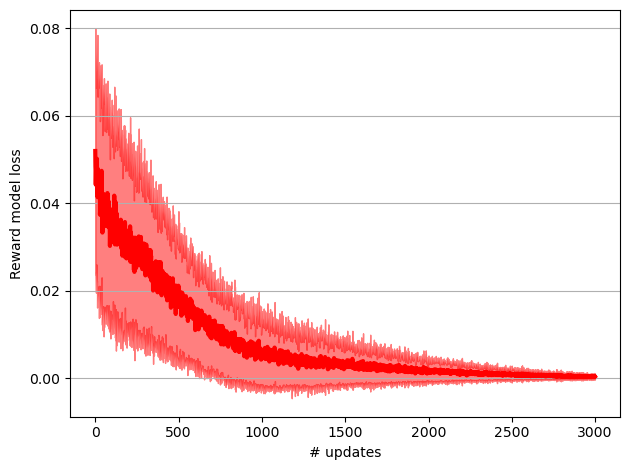

In [8]:
mean_loss, std_loss = np.mean(r_loss, 0), np.std(r_loss, 0)
# for d6in range(n_r_models):
#     plt.plot(r_loss[d], lw=0.2, c="r")
plt.plot(np.arange(n_epochs), mean_loss, lw=3, c="r")
plt.fill_between(np.arange(n_epochs), mean_loss - std_loss, mean_loss + std_loss, color="r", alpha=0.5)
plt.xlabel("# updates")
plt.ylabel("Reward model loss")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(main_dir +"/ensemble_reward_models/reward_mean_loss_600.pdf", dpi=300)

# Plants 3 channels

In [5]:
batch_1 = replay_buffer_1.process_batch(replay_buffer_1.sample(len(replay_buffer_1) -1), device=device)
unmonitor_ind_1= np.where(batch_1["mon_obs"].cpu().numpy() == 1)[0]
plant_channels_1 = batch_1["mdp_obs"][unmonitor_ind_1][:, 1:4, center_indx, center_indx].cpu().numpy()

# batch_2 = replay_buffer_2.process_batch(replay_buffer_2.sample(len(replay_buffer_2) -1), device=device)
# unmonitor_ind_2= np.where(batch_2["mon_obs"].cpu().numpy() == 1)[0]
# plant_channels_2 = batch_2["mdp_obs"][unmonitor_ind_2][:, 1:4, center_indx, center_indx].cpu().numpy()

# batch_3 = replay_buffer_3.process_batch(replay_buffer_3.sample(len(replay_buffer_3) -1), device=device)
# unmonitor_ind_3= np.where(batch_3["mon_obs"].cpu().numpy() == 1)[0]
# plant_channels_3 = batch_3["mdp_obs"][unmonitor_ind_3][:, 1:4, center_indx, center_indx].cpu().numpy()

In [6]:
plant_indx = []
cactus_indx = []
diff_1_indx, diff_2_indx, diff_3_indx, diff_4_indx, diff_5_indx = [], [], [], [], []
for i, row in enumerate(plant_channels_1):
    if (row == np.array([0, 1, 1])).all():
        cactus_indx.append(i)
    if (row == np.array([1, 1, 0])).all():
        plant_indx.append(i)
    if (row == np.array([0, 0, 1])).all():
        diff_1_indx.append(i)
    if (row == np.array([0, 1, 0])).all():
        diff_2_indx.append(i)
    if (row == np.array([1, 0, 0])).all():
        diff_3_indx.append(i)
    if (row == np.array([1, 0, 1])).all():
        diff_4_indx.append(i)
    if (row == np.array([1, 1, 1])).all():
        diff_5_indx.append(i)
len(plant_indx), len(cactus_indx), len(diff_1_indx), len(diff_2_indx), len(diff_3_indx), len(diff_4_indx), len(diff_5_indx)

(21434, 19512, 110, 124, 100, 106, 94)

In [7]:
n_r_models = 200
trained_models = []
for r in range(n_r_models):
    trained_models.append(torch.load(main_dir + "/ensemble_reward_models/reward_model_{}".format(r)))

In [8]:
plants_reward = np.zeros((len(plant_indx), n_r_models, n_mdp_actions))
cactus_reward = np.zeros((len(cactus_indx), n_r_models, n_mdp_actions))
diff_1_reward = np.zeros((len(diff_1_indx), n_r_models, n_mdp_actions))
diff_2_reward = np.zeros((len(diff_2_indx), n_r_models, n_mdp_actions))
diff_3_reward = np.zeros((len(diff_3_indx), n_r_models, n_mdp_actions))
diff_4_reward = np.zeros((len(diff_4_indx), n_r_models, n_mdp_actions))
diff_5_reward = np.zeros((len(diff_5_indx), n_r_models, n_mdp_actions))
for r in range(n_r_models):
    plants_reward[:, r] = trained_models[r]._network(batch_1["mdp_obs"][unmonitor_ind_1][plant_indx]).detach().cpu().numpy()
    cactus_reward[:, r] = trained_models[r]._network(batch_1["mdp_obs"][unmonitor_ind_1][cactus_indx]).detach().cpu().numpy()
    diff_1_reward[:, r] = trained_models[r]._network(batch_1["mdp_obs"][unmonitor_ind_1][diff_1_indx]).detach().cpu().numpy()

    diff_2_reward[:, r] = trained_models[r]._network(batch_1["mdp_obs"][unmonitor_ind_1][diff_2_indx]).detach().cpu().numpy()
    diff_3_reward[:, r] = trained_models[r]._network(batch_1["mdp_obs"][unmonitor_ind_1][diff_3_indx]).detach().cpu().numpy()
    diff_4_reward[:, r] = trained_models[r]._network(batch_1["mdp_obs"][unmonitor_ind_1][diff_4_indx]).detach().cpu().numpy()
    diff_5_reward[:, r] = trained_models[r]._network(batch_1["mdp_obs"][unmonitor_ind_1][diff_5_indx]).detach().cpu().numpy()

In [10]:
np.round(np.mean(plants_reward[8], 0), 3), np.round(np.std(plants_reward[2], 0), 3)

(array([-0.   ,  0.   ,  0.   , -0.   ,  1.079, -0.   ]),
 array([0.003, 0.004, 0.004, 0.004, 0.114, 0.004]))

In [11]:
np.round(np.mean(cactus_reward[1], 0), 3), np.round(np.std(cactus_reward[1], 0), 3)

(array([ 0.000e+00,  1.000e-03, -0.000e+00, -0.000e+00, -1.138e+00,
         0.000e+00]),
 array([0.003, 0.004, 0.004, 0.004, 0.066, 0.004]))

In [12]:
np.round(np.mean(diff_1_reward[1], 0), 3), np.round(np.std(diff_1_reward[1], 0), 3)

(array([ 0.   , -0.   , -0.   ,  0.   , -0.344,  0.   ]),
 array([0.005, 0.004, 0.004, 0.004, 0.124, 0.004]))

In [13]:
np.round(np.mean(diff_2_reward[1], 0), 3), np.round(np.std(diff_2_reward[1], 0), 3)

(array([ 0.   , -0.   , -0.   , -0.   ,  0.612,  0.   ]),
 array([0.005, 0.005, 0.005, 0.005, 0.109, 0.005]))

In [14]:
np.round(np.mean(diff_3_reward[1], 0), 3), np.round(np.std(diff_3_reward[1], 0), 3)

(array([-0.000e+00,  0.000e+00,  0.000e+00, -1.000e-03,  1.154e+00,
        -0.000e+00]),
 array([0.006, 0.006, 0.007, 0.006, 0.094, 0.006]))

In [15]:
np.round(np.mean(diff_4_reward[1], 0), 3), np.round(np.std(diff_4_reward[1], 0), 3)

(array([ 0.001,  0.   ,  0.   , -0.   ,  0.401,  0.   ]),
 array([0.005, 0.007, 0.006, 0.006, 0.186, 0.006]))

In [16]:
np.round(np.mean(diff_4_reward[1], 0), 3), np.round(np.std(diff_4_reward[1], 0), 3)

(array([ 0.001,  0.   ,  0.   , -0.   ,  0.401,  0.   ]),
 array([0.005, 0.007, 0.006, 0.006, 0.186, 0.006]))

# plot histogram for plants vs cactus in unmonitor room

In [5]:
n_r_models = 500
trained_models = []
for r in range(n_r_models):
    trained_models.append(torch.load(main_dir + "/ensemble_reward_models/reward_model_{}".format(r), weights_only=False))

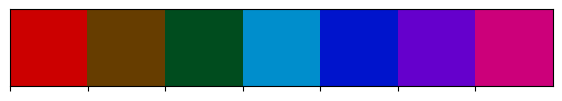

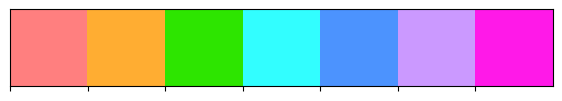

In [6]:
from src.k_of_n_measure import get_rewards, load_replay_buffer
from src.policy_analysis import set_blind_colors
light_colors, dark_colors = set_blind_colors()

In [7]:
buffer = load_replay_buffer(grid_size, window_size, dryness, seed=4, device="mps:0")

In [8]:
reward_dict = get_rewards(window_size, n_mdp_actions, trained_models, buffer)

In [45]:
labels = {"plant": "Plant",
        "cactus": "Cactus",
        "diff_1": "[0, 0, 1]",
        "diff_2": "[0, 1, 0]",
        "diff_3": "[1, 0, 0]",
        "diff_4": "[1, 0, 1]",
        "diff_5": "[1, 1, 1]",
}

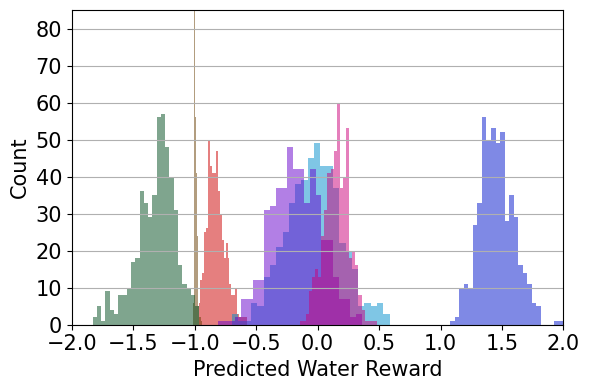

In [64]:
fig = plt.figure(figsize=(6, 4))
for i, l in enumerate(labels):
    plt.hist(reward_dict[l][1, :, 4], density=False, bins=bins, color=dark_colors[i], alpha=0.5, label=labels[l])

plt.xlabel("Predicted Water Reward", fontsize=15)
plt.ylabel("Count", fontsize=15)
plt.grid(axis="y")
# plt.legend(fontsize=15)
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.ylim(0, 85)
plt.xlim(-2, 2)
plt.tight_layout()
# plt.savefig(main_dir + "/reward_ensemble_precitions_plants.pdf", dpi=300)

In [27]:
reward_dict

'../general_models/Plants/reward_model/10_10_channel/dry_0.05/3_room/window_11/eps_decay_1e-07/q_lr_0.0001/reward_lr_0.0001'

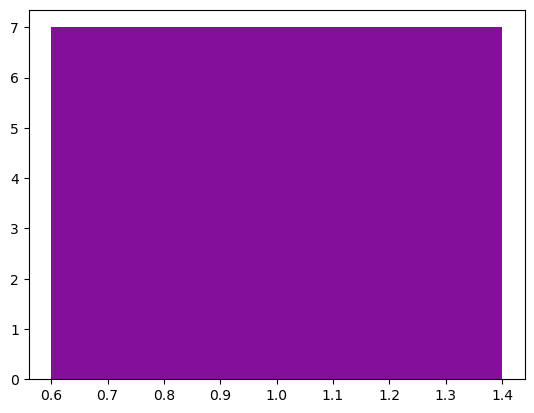

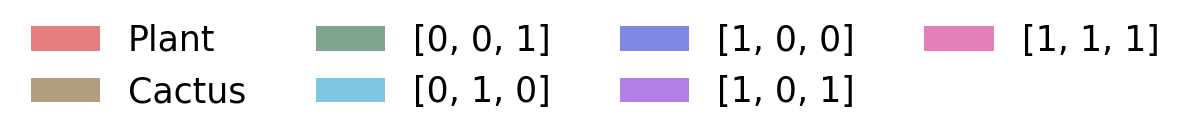

In [65]:
legends = ["Plant", "Cactus", "[0, 0, 1]", "[0, 1, 0]", "[1, 0, 0]", "[1, 0, 1]", "[1, 1, 1]"]
f = lambda m,c: plt.bar(1, len(legends), color=c, alpha=0.5)[0]
handles = [f("s", dark_colors[i]) for i in range(len(legends))]
fig = plt.figure(figsize=(12, 1.2))
fig.legend(handles, legends, fontsize=25, ncol=4, loc='center', frameon=False)
fig.gca().set_axis_off()
plt.tight_layout()
# plt.savefig("../general_models/Plants/reward_model/legend_plant_types_col_4.pdf", dpi=300)

In [69]:
replay_buffer_1 = TorchReplayMemory(int(1e6))
replay_buffer_1.load(main_dir + "/checkpoints_{}/".format(1), seed=4)

replay_buffer_2 = TorchReplayMemory(int(1e6))
replay_buffer_2.load(main_dir + "/checkpoints_{}/".format(2), seed=4)

replay_buffer_3 = TorchReplayMemory(int(1e6))
replay_buffer_3.load(main_dir + "/checkpoints_{}/".format(3), seed=4)

In [70]:
batch_1 = replay_buffer_1.process_batch(replay_buffer_1.sample(len(replay_buffer_1) -1), device=device)
unmonitor_ind_1= np.where(batch_1["mon_obs"].cpu().numpy() == 1)[0]
plants_indx_1 = np.where(batch_1["mdp_obs"][unmonitor_ind_1][:, 1, center_indx, center_indx].cpu().numpy() == 1.0)[0]
cactus_indx_1 = np.where(batch_1["mdp_obs"][unmonitor_ind_1][:, 1, center_indx, center_indx].cpu().numpy() == 0.5)[0]

batch_2 = replay_buffer_2.process_batch(replay_buffer_2.sample(len(replay_buffer_2) -1), device=device)
unmonitor_ind_2= np.where(batch_2["mon_obs"].cpu().numpy() == 1)[0]
plants_indx_2 = np.where(batch_2["mdp_obs"][unmonitor_ind_2][:, 1, center_indx, center_indx].cpu().numpy() == 1.0)[0]
cactus_indx_2 = np.where(batch_2["mdp_obs"][unmonitor_ind_2][:, 1, center_indx, center_indx].cpu().numpy() == 0.5)[0]


batch_3 = replay_buffer_3.process_batch(replay_buffer_3.sample(len(replay_buffer_3) -1), device=device)
unmonitor_ind_3= np.where(batch_3["mon_obs"].cpu().numpy() == 1)[0]
plants_indx_3 = np.where(batch_3["mdp_obs"][unmonitor_ind_3][:, 1, center_indx, center_indx].cpu().numpy() == 1.0)[0]
cactus_indx_3 = np.where(batch_3["mdp_obs"][unmonitor_ind_3][:, 1, center_indx, center_indx].cpu().numpy() == 0.5)[0]

In [ ]:
plants_reward_1 = np.zeros((len(plants_indx_1), n_r_models, n_mdp_actions))
plants_reward_2 = np.zeros((len(plants_indx_2), n_r_models, n_mdp_actions))
plants_reward_3 = np.zeros((len(plants_indx_3), n_r_models, n_mdp_actions))

cactus_reward_1 = np.zeros((len(cactus_indx_1), n_r_models, n_mdp_actions))
cactus_reward_2 = np.zeros((len(cactus_indx_2), n_r_models, n_mdp_actions))
cactus_reward_3 = np.zeros((len(cactus_indx_3), n_r_models, n_mdp_actions))
for r in range(n_r_models):
    plants_reward_1[:, r] = trained_models[r]._network(batch_1["mdp_obs"][unmonitor_ind_1][plants_indx_1]).detach().cpu().numpy()
    plants_reward_2[:, r] = trained_models[r]._network(batch_2["mdp_obs"][unmonitor_ind_2][plants_indx_2]).detach().cpu().numpy()
    plants_reward_3[:, r] = trained_models[r]._network(batch_3["mdp_obs"][unmonitor_ind_3][plants_indx_3]).detach().cpu().numpy()

    cactus_reward_1[:, r] = trained_models[r]._network(batch_1["mdp_obs"][unmonitor_ind_1][cactus_indx_1]).detach().cpu().numpy()
    cactus_reward_2[:, r] = trained_models[r]._network(batch_2["mdp_obs"][unmonitor_ind_2][cactus_indx_2]).detach().cpu().numpy()
    cactus_reward_3[:, r] = trained_models[r]._network(batch_3["mdp_obs"][unmonitor_ind_3][cactus_indx_3]).detach().cpu().numpy()

In [ ]:
plt.hist(plants_reward_1[8, :, 4], density=False, bins=bins, color="b", alpha=0.7, label="Plants")
plt.hist(cactus_reward_1[5, :, 4], density=False, bins=bins, color="r", alpha=0.7, label="cactus")

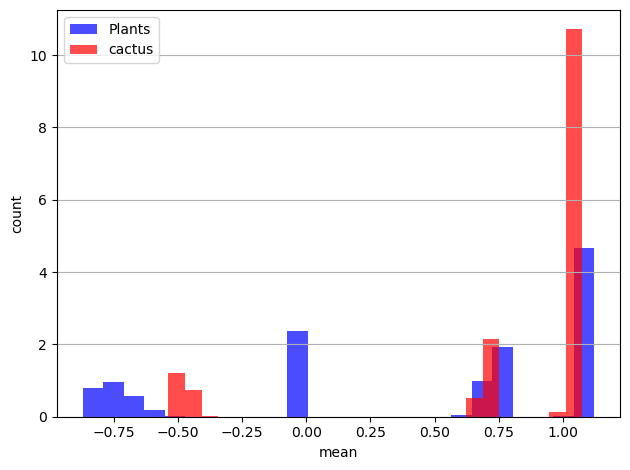

In [22]:
plt.hist(np.mean(plants_reward_3, 1)[:, 4], density=True, bins=bins, color="b", alpha=0.7, label="Plants")
plt.hist(np.mean(cactus_reward_3, 1)[:, 4], density=True, bins=bins, color="r", alpha=0.7, label="cactus")
plt.xlabel("mean")
plt.ylabel("count")
plt.grid(axis="y")
plt.legend()
plt.tight_layout()
plt.savefig(main_dir +"/hist_plants_cactus_mean_buffer_3.pdf", dpi=300)

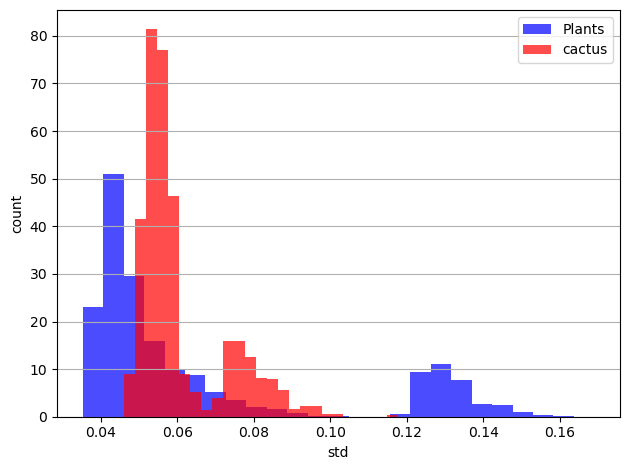

In [16]:
plt.hist(np.std(plants_reward_1, 1)[:, 4], density=True, bins=bins, color="b", alpha=0.7, label="Plants")
plt.hist(np.std(cactus_reward_1, 1)[:, 4], density=True, bins=bins, color="r", alpha=0.7, label="cactus")
plt.xlabel("std")
plt.ylabel("count")
plt.grid(axis="y")
plt.legend()
plt.tight_layout()
plt.savefig(main_dir +"/hist_plants_cactus_std_buffer_1.pdf", dpi=300)

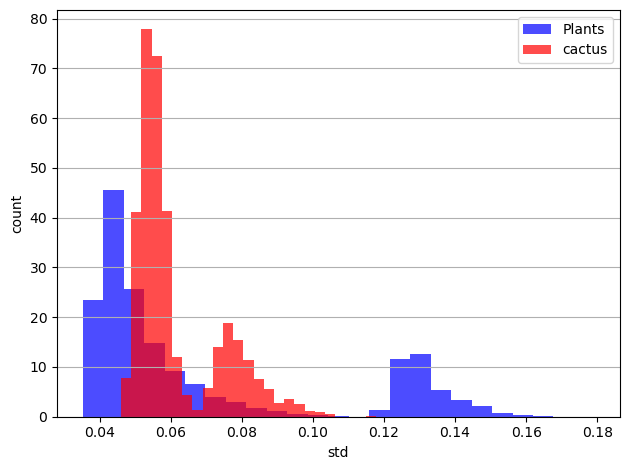

In [17]:
plt.hist(np.std(plants_reward_2, 1)[:, 4], bins=bins, density=True, color="b", alpha=0.7, label="Plants")
plt.hist(np.std(cactus_reward_2, 1)[:, 4], bins=bins, density=True, color="r", alpha=0.7, label="cactus")
plt.xlabel("std")
plt.ylabel("count")
plt.grid(axis="y")
plt.legend()
plt.tight_layout()
plt.savefig(main_dir +"/hist_plants_cactus_std_buffer_2.pdf", dpi=300)

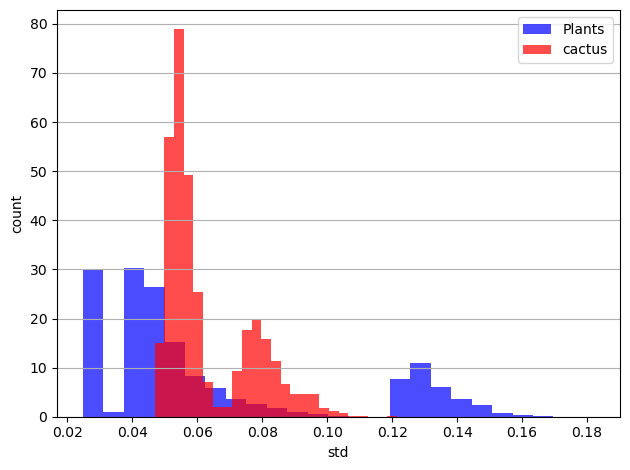

In [18]:
plt.hist(np.std(plants_reward_3, 1)[:, 4], bins=bins, density=True, color="b", alpha=0.7, label="Plants")
plt.hist(np.std(cactus_reward_3, 1)[:, 4], bins=bins, density=True, color="r", alpha=0.7, label="cactus")
plt.xlabel("std")
plt.ylabel("count")
plt.grid(axis="y")
plt.legend()
plt.tight_layout()
plt.savefig(main_dir +"/hist_plants_cactus_std_buffer_3.pdf", dpi=300)

# k-of-N

In [6]:
batch_1 = replay_buffer_1.process_batch(replay_buffer_1.sample(len(replay_buffer_1) -1), device=device)
batch_2 = replay_buffer_2.process_batch(replay_buffer_2.sample(len(replay_buffer_2) -1), device=device)
batch_3 = replay_buffer_3.process_batch(replay_buffer_3.sample(len(replay_buffer_3) -1), device=device)

unmonitor_ind_1= np.where(batch_1["mon_obs"].cpu().numpy() == 1)[0]
unmonitor_ind_2= np.where(batch_2["mon_obs"].cpu().numpy() == 1)[0]
unmonitor_ind_3= np.where(batch_3["mon_obs"].cpu().numpy() == 1)[0]

cactus_indx_1 = np.where(batch_1["mdp_obs"][unmonitor_ind_1][:, 1, 4, 4].cpu().numpy() == 0.5)[0]
plants_indx_1 = np.where(batch_1["mdp_obs"][unmonitor_ind_1][:, 1, 4, 4].cpu().numpy() == 1.0)[0]

cactus_indx_2 = np.where(batch_1["mdp_obs"][unmonitor_ind_2][:, 1, 4, 4].cpu().numpy() == 0.5)[0]
plants_indx_2 = np.where(batch_1["mdp_obs"][unmonitor_ind_2][:, 1, 5, 5].cpu().numpy() == 1.0)[0]

cactus_indx_3 = np.where(batch_1["mdp_obs"][unmonitor_ind_3][:, 1, 4, 4].cpu().numpy() == 0.5)[0]
plants_indx_3 = np.where(batch_1["mdp_obs"][unmonitor_ind_3][:, 1, 4, 4].cpu().numpy() == 1.0)[0]

IndexError: index 4 is out of bounds for dimension 2 with size 3

In [5]:
n_r_models = 400
n_iterations = 100
k = 1
n = 100

In [6]:
trained_models = []
for r in range(n_r_models):
    trained_models.append(torch.load(main_dir + "/ensemble_reward_models/reward_model_{}".format(r)))

In [22]:
def sort_and_k_least (array, k):
    '''
    sort a tensor from small value to big value and select lowest k values
    Inputs:
    array: (tesnor) tensor we want to sort it
    k: (int) size of lowest values
    return:
    numpy array (shape (k, ))
    '''
    return array.argsort()[:k]

def evalaute_obs(obs, models):
    values = np.zeros((len(models), n_mdp_actions))
    for i, model in enumerate(models):
        values[i] = model._network(obs).detach().cpu().numpy()
    return values

def transition(obs: np.ndarray, action: int) -> np.ndarray:
    return channel_env.observation(window_env.observation(wall_env.observation(env.transit(s, action))))

def k_of_n_policy(obs, k: int, n: int, terminated: bool, gamma: float = 0.99):
    obs_reward_value = evalaute_obs(obs, trained_models)
    action = (1 / n_mdp_actions) * np.ones((1, n_mdp_actions))
    total_regret = np.zeros((1, n_mdp_actions))
    expected_kof_n = []
    for itr in range(n_iterations):
        n_models = obs_reward_value[np.random.choice(n_r_models, n)]
        k_index = sort_and_k_least(np.sum(n_models * action, 1), k)
        mean_k = np.mean(n_models[k_index], 0)
        value_mean_k = np.sum(mean_k * action)
        
        expected_kof_n.append(value_mean_k)
        next_q = 0
        regret = (mean_k - value_mean_k) + gamma * next_q * (1 - terminated)
        total_regret += regret
        # total_regret += np.maximum(0, regret)
        action = np.maximum(0, total_regret) / np.sum(np.maximum(0, total_regret))
    return action, expected_kof_n,  np.argmax(action[0])

In [68]:
cactus_obs = batch_1["mdp_obs"][unmonitor_ind_1][cactus_indx_1[594]].unsqueeze(0)
plant_obs = batch_3["mdp_obs"][25].unsqueeze(0) #batch_1["mdp_obs"][unmonitor_ind_1][plants_indx_1[69]].unsqueeze(0)
cactus_reward_value = evalaute_obs(cactus_obs, trained_models)
plant_reward_value = evalaute_obs(plant_obs, trained_models)
print(cactus_obs[0, 1:3, 4, 4])
print(plant_obs[0, 1:3, 4, 4])

tensor([0.5000, 0.5000], device='mps:0')
tensor([0.5000, 0.0000], device='mps:0')


In [75]:
action = (1 / n_mdp_actions) * np.ones((1, n_mdp_actions))
total_regret = np.zeros((1, n_mdp_actions))
expected_kof_n = []
for itr in range(n_iterations):
    n_models = cactus_reward_value[np.random.choice(n_r_models, n)]
    k_index = sort_and_k_least(np.sum(n_models * action, 1), k)
    mean_k = np.mean(n_models[k_index], 0)
    value_mean_k = np.sum(mean_k * action)
    
    expected_kof_n.append(value_mean_k)
    regret = mean_k - value_mean_k
    total_regret += regret
    action = np.maximum(0, total_regret) / np.sum(np.maximum(0, total_regret))
print(action)

[[0. 0. 0. 0. 1. 0.]]


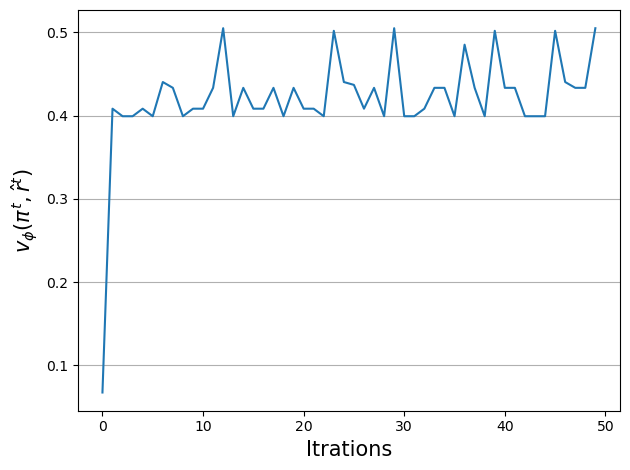

In [77]:
plt.plot(expected_kof_n)
plt.xlabel("Itrations", fontsize=15)
plt.ylabel(r"$v_{\phi}(\pi^t, \hat{r}^t)$", fontsize=15)
plt.grid(axis="y")
plt.tight_layout()

In [22]:
np.where((batch_3["mdp_obs"].cpu().numpy()[:, 3, 0, 2] == 1) & (batch_3["mdp_obs"].cpu().numpy()[:, 1, 1, 1] == 1.0))[0]

array([    25,     46,    126, ..., 999974, 999981, 999983])

In [23]:
batch_3["mdp_obs"][25], batch_3["mon_obs"][25]

(tensor([[[0.0000, 0.0000, 0.0000],
          [0.0000, 1.0000, 0.0000],
          [0.0000, 0.0000, 0.0000]],
 
         [[0.0000, 0.0000, 0.0000],
          [0.0000, 1.0000, 0.0000],
          [0.5000, 0.0000, 1.0000]],
 
         [[0.0000, 0.0000, 0.0000],
          [0.0000, 1.0000, 0.0000],
          [1.0000, 0.0000, 0.0000]],
 
         [[1.0000, 1.0000, 1.0000],
          [0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000]]], device='mps:0'),
 tensor([0.], device='mps:0'))

In [39]:
np.mean(cactus_reward_value[:, 4]), np.std(cactus_reward_value[:, 4])

(0.7049374648332596, 0.07368513117211625)

In [40]:
np.mean(plant_reward_value[:, 4]), np.std(plant_reward_value[:, 4])

(-0.4682537233233452, 0.08182917653698941)

In [8]:
q_model = torch.load(main_dir + "/q_network_{}".format(1))
def select_action(q_values) -> int:
    """Choose an action from a Q value distribution/ break ties to a random action"""
    indices = np.argwhere(q_values == np.max(q_values))
    return random.choice(indices)[0]

In [ ]:
ep_reward = []
for i in range(1):
    s, _ = env.reset()
    total_r, timestep, spill, cactus, water_plant = 0, 0, 0, 0, 0
    done = False
    actions, mdp_s, mon_s = [], [], []
    cactus_obs, plants_obs = [], []
    action_probs = []
    env.render()
    while timestep < 100:
        mdp_obs = torch.tensor(s["mdp"], dtype=torch.float32, device=device).unsqueeze(0)
        mon_obs = torch.tensor([s["monitor"]], dtype=torch.float32, device=device).unsqueeze(0)
        mdp_s.append(mdp_obs)
        mon_s.append(mon_obs)
        # action = env.action_space.sample()["mdp"]

        # with torch.no_grad():
        #     q_values = q_model[5:](torch.concat((q_model[:5](mdp_obs), mon_obs), 1))
        # action = select_action(q_values.cpu().numpy().squeeze())

        action_prob , _, action = k_of_n_policy(mdp_obs, 10, 40)
        action_probs.append(action_prob)
        
        actions.append(action)
        plant = env.get_grid()[1, env.get_agent_pos()[0], env.get_agent_pos()[1]]
        if plant == 0.5:
            cactus_obs.append(mdp_obs)
        if plant == 1:
            plants_obs.append(mdp_obs)
        next_s = transition(s, action)
        s, r, done, _, info = env.step({"mdp": action, "monitor": 0})
        # print((s["mdp"] == next_s).all())
        if action == 4:
            if plant == 0.0:  # spill water in the floor
                spill += 1
            if plant == 0.5: # water cactus
                cactus += 1
                print("r", info["mdp_reward"])
            else:
                water_plant += 1
        reward = info["mdp_reward"] + r["monitor"]
        total_r += reward * (gamma**timestep)
        timestep += 1
        env.render()
    ep_reward.append(total_r)
    print("spill", spill)
    print("cactus", cactus)
    print("water_plant", water_plant)
actions = np.squeeze(actions)
# env.close()

In [10]:
len(plants_obs), len(cactus_obs)

(0, 0)

In [45]:
cactus_values = np.zeros((n_r_models, n_mdp_actions))
plants_values = np.zeros((n_r_models, n_mdp_actions))
for r in range(n_r_models):
    cactus_values[r] = trained_models[r]._network(cactus_obs[0]).detach().cpu().numpy()
    plants_values[r] = trained_models[r]._network(plants_obs[0]).detach().cpu().numpy()

In [46]:
print(np.round(np.mean(plants_values, 0), 2), np.round(np.std(plants_values, 0), 2), "\n")
print(np.round(np.mean(cactus_values, 0), 2), np.round(np.std(cactus_values, 0), 2))

[-0.    0.   -0.   -0.    0.99  0.  ] [0.01 0.01 0.01 0.01 0.05 0.01] 

[-0.   -0.   -0.   -0.    0.92 -0.  ] [0.01 0.01 0.   0.01 0.06 0.  ]


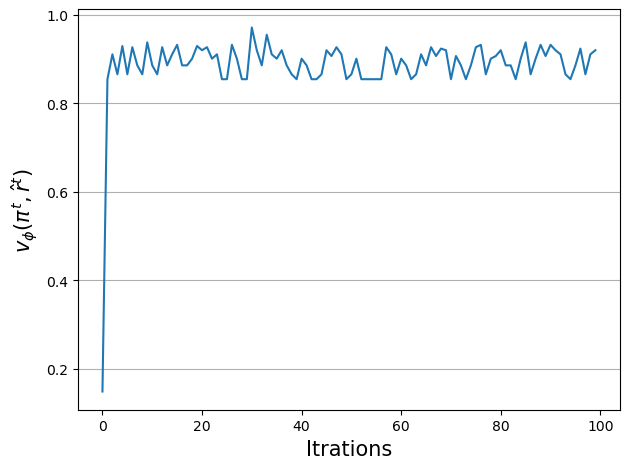

In [42]:
prob, ex, _ = k_of_n_policy(plants_obs[0], 1, 20)
plt.plot(ex)
plt.xlabel("Itrations", fontsize=15)
plt.ylabel(r"$v_{\phi}(\pi^t, \hat{r}^t)$", fontsize=15)
plt.grid(axis="y")
plt.tight_layout()

In [49]:
current_obs = mdp_s[79]#cactus_obs[6]
current_obs[0][4]

tensor([[0., 0., 0.],
        [1., 0., 0.],
        [0., 0., 0.]], device='mps:0')

In [50]:
prob, ex, ac = k_of_n_policy(current_obs, 1, 20)
with torch.no_grad():
    q_v = q_model[5:](torch.concat((q_model[:5](current_obs), torch.tensor([[0.]], device=device)), 1))
print("k-of-N", ac, np.round(prob, 3))
print("Q", select_action(q_v.cpu().numpy().squeeze()), np.round(q_v.detach().cpu().numpy(), 3))

k-of-N 0 [[0.329 0.228 0.122 0.115 0.    0.206]]
Q 3 [[3.257 3.289 1.787 3.496 3.026 3.254]]


In [172]:
print(np.round(np.mean(evalaute_obs(current_obs, trained_models), 0), 3),"\n",np.round(np.std(evalaute_obs(current_obs, trained_models), 0), 3))

[ 0.     0.     0.    -0.    -0.222  0.001] 
 [0.003 0.004 0.003 0.003 0.091 0.004]


In [31]:
np.round(np.mean(cactus_values, 0), 2), np.round(np.std(cactus_values, 0), 2)

(array([-0.  ,  0.01,  0.02,  0.02,  0.51, -0.01]),
 array([0.26, 0.27, 0.3 , 0.25, 0.31, 0.28]))

In [56]:
mon_obs, torch.tensor([[1.0]], device=device)

(tensor([[1.]], device='mps:0'), tensor([[1.]], device='mps:0'))